In [52]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, time

### Select feature for testing
- 3 months of data

In [2]:
mso = gpd.read_file('../maps/mso_features.gpk')

/home/vince/miniconda3/envs/ox/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: File ../maps/mso_features.gpk has GPKG application_id, but non conformant file extension
  return ogr_read(
/home/vince/miniconda3/envs/ox/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Table/view mso_features is referenced in gpkg_contents, but does not exist
  return ogr_read(
/home/vince/miniconda3/envs/ox/lib/python3.9/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'mso_features.gpk': 'parks' (default), 'pitches', 'sports_centres', 'schools'. Specify layer parameter to avoid this warning.
  result = read_func(


In [ ]:
# convert to WGS84
mso = mso.to_crs(epsg=4326)

fort_mso = mso[mso['name'].str.contains(r'Fort|McCormick', case=False, na=False)]

fort_mso.to_file('fort_mso.geojson', driver='GeoJSON')

In [33]:
fort_mso

,element,id,leisure,name,sport,access,manufacturer,surface,amenity,ele,...,courts,park,not:brand:wikidata,tourism,type,addr:country,isced:level,landuse,nohousenumber,geometry
24,way,111876397,park,McCormick Park,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-114.00512 46.87446, -114.00466 46.8..."
29,way,112543194,park,Little McCormick Park,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-114.00159 46.87795, -114.00159 46.8..."
81,way,603932847,park,Fort Missoula Regional Park,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-114.05539 46.84868, -114.05541 46.8..."


## Pin report
- did the 'dayparts' selections matter? do we have data from the entire time period?

In [36]:
pins = pd.read_csv("4657461_McormickPark_3months_VC_061925_pin_report.tsv", sep='\t')

In [57]:
times = pins['Time of Day'].apply(lambda x: datetime.strptime(x, '%H:%M:%S'))

In [58]:
times

0      1900-01-01 23:13:04
1      1900-01-01 16:45:30
2      1900-01-01 16:47:52
3      1900-01-01 16:48:37
4      1900-01-01 16:49:17
               ...        
7446   1900-01-01 18:49:36
7447   1900-01-01 18:49:39
7448   1900-01-01 18:49:36
7449   1900-01-01 18:49:38
7450   1900-01-01 18:49:39
Name: Time of Day, Length: 7451, dtype: datetime64[ns]

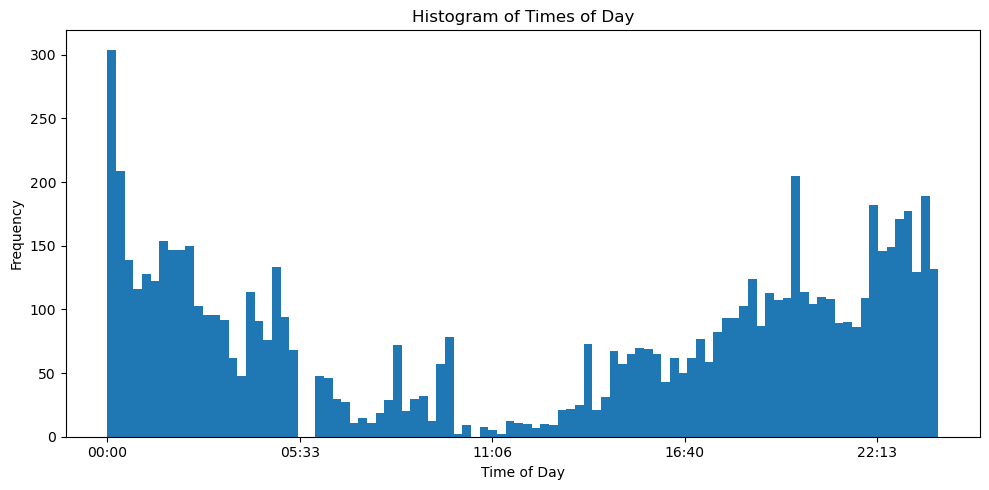

In [60]:
# Step 1: Convert to seconds since midnight
seconds_since_midnight = times.dt.hour * 3600 + times.dt.minute * 60 + times.dt.second

# Step 2: Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(seconds_since_midnight, bins=24*4)  # 15-min bins

# Step 3: Format x-axis as time labels
from matplotlib.ticker import FuncFormatter

def format_func(x, pos):
    hours = int(x // 3600)
    minutes = int((x % 3600) // 60)
    return f'{hours:02d}:{minutes:02d}'

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_func))
plt.xlabel("Time of Day")
plt.ylabel("Frequency")
plt.title("Histogram of Times of Day")
plt.tight_layout()
plt.show()



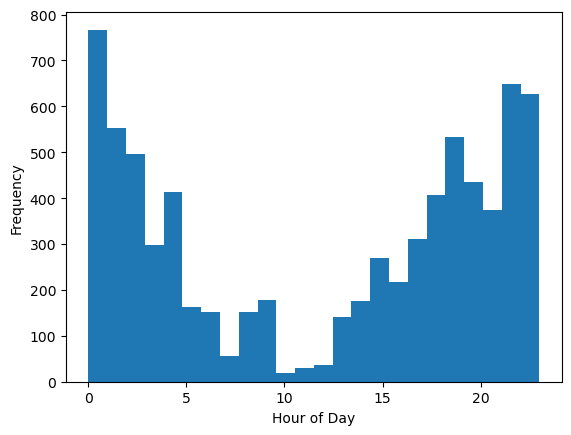

In [61]:
times.dt.hour.plot.hist(bins=24)
plt.xlabel("Hour of Day")
plt.show()